<a href="https://colab.research.google.com/github/shobhit-05/cse493s-spring26-hw1/blob/linda/part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 Test-Time Scaling

This notebook loads an AIME 2024 dataset, runs a model on each problem, extracts an AIME-style final answer, and grades the outputs.

In [ ]:
import re

import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# !pip install vllm==0.20.0
from vllm import LLM, SamplingParams

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

In [ ]:
MODEL_NAME = "Qwen/Qwen3-4B"
# or allenai/Olmo-3-7B-Thinking
DATASET_NAME = "OpenRLHF/aime-2024"
MAX_NEW_TOKENS = 34000

## Loading the model and the data

In [ ]:
import os
import sys

# Using vLLM instead for faster inference
dtype = "float16" if torch.cuda.is_available() else "float32"

#avoid fileno() error in google colab
original_stdout = sys.stdout
original_stderr = sys.stderr
sys.stdout = open(os.devnull, 'w')
sys.stderr = open(os.devnull, 'w')

try:
    llm = LLM(model=MODEL_NAME, dtype=dtype, max_model_len=MAX_NEW_TOKENS, hf_token=HF_TOKEN, gpu_memory_utilization=0.99)
finally:
    sys.stdout.close()
    sys.stderr.close()
    sys.stdout = original_stdout
    sys.stderr = original_stderr

tokenizer = llm.get_tokenizer()

dataset = load_dataset(DATASET_NAME, split="train", token=HF_TOKEN)

## Evaluation helpers

In [ ]:

from collections import Counter

def majority(answers):
    valid = [a for a in answers]
    return Counter(valid).most_common(1)[0][0] if valid else None

def extract_thinking_trace(text):
    # complete thinking
    match = re.search(r'<think>(.*?)</think>', text, re.DOTALL)
    if match:
        return match.group(1).strip()
    # truncated due to max tokens
    match = re.search(r'<think>(.*)', text, re.DOTALL)
    return match.group(1).strip() if match else ""

def think_end_ids(tokenizer):
    for tag in ["<|/thinking|>", "</think>"]:
        ids = tokenizer.encode(tag, add_special_tokens=False)
        if ids:
            return ids, tag

def make_prompt_think(text, tokenizer):
    msgs = [
        {"role": "system", "content": "You are a careful competition math assistant. Always output your final answer in \\boxed{}."},
        {"role": "user",   "content": text},
    ]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=True)

def strip_thinking_trace(text):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(r"<\|begin_of_thought\|>.*?<\|end_of_thought\|>", "", text, flags=re.DOTALL)
    return text.strip()


def extract_answer(text: str, mode="exact_match") -> int | None:
    """Extract an AIME-style integer answer from a model completion."""
    answer_text = strip_thinking_trace(text)
    if not answer_text:
        if mode == "exact_match":
            return None
        else:
            answer_text = text  # fall back to full text


    # 1. Boxed LaTeX answer: \boxed{123}
    if mode == "exact_match":
        boxed = re.findall(r"\\boxed\{(\d+)\}", answer_text)
        if boxed:
            val = int(boxed[-1])
            return val
        else:
            return None

    elif mode == "flexible_extract":
        # 2. "The answer is N" or "answer: N" patterns
        patterns = [
            r"(?:the\s+)?answer\s+is\s+[:\s]*(\d+)",
            r"answer[:\s]+(\d+)",
            r"=\s*(\d+)\s*$",
            r"(?:therefore|thus|so),?\s+(\d+)\s*(?:\.|$)",
        ]
        for pattern in patterns:
            matches = re.findall(pattern, answer_text, re.IGNORECASE)
            if matches:
                val = int(matches[-1])
                return val

        # 3. Last integer in [0, 999] in the answer portion
        integers = re.findall(r"\b(\d{1,3})\b", answer_text)
        for candidate in reversed(integers):
            val = int(candidate)
            return val
        return None


## 2.1 Warm-Up

It was run separately with MAX_NEW_TOKENS = 8192

In [ ]:
#vLLM instead!
ANSWER_MODE = 'flexible_extract'
prompts, gold_answers, problems = [], [], []
for example in dataset:
    problem = example["prompt"][0]["content"]
    problems.append(problem)
    gold_answers.append(int(example["label"]))
    prompts.append(tokenizer.apply_chat_template(
        [{"role": "system", "content": "You are a careful competition math assistant. Always output your final answer in \\boxed{}."},
         {"role": "user",   "content": problem}],
        tokenize=False, add_generation_prompt=True, enable_thinking=True,
    ))

sampling = SamplingParams(temperature=0.0, max_tokens=MAX_NEW_TOKENS, detokenize=True, skip_special_tokens=False)
outputs  = llm.generate(prompts, sampling_params=sampling)

print("RAW OUTPUT SNIPPET:", repr(outputs[0].outputs[0].text[:300]))

records = []
for i, (out, gold, problem) in enumerate(zip(outputs, gold_answers, problems)):
    model_output = out.outputs[0].text
    extracted    = extract_answer(model_output, mode=ANSWER_MODE)
    correct      = extracted == gold if extracted is not None else False
    thinking     = extract_thinking_trace(model_output)
    think_len    = len(tokenizer.encode(thinking, add_special_tokens=False))

    records.append(dict(problem=problem, gold_answer=gold, model_output=model_output,
                        extracted_answer=extracted, correct=correct, thinking_length=think_len))
    print(f"[{i+1}/{len(dataset)}] gold={gold} pred={extracted} correct={correct} thinking_len={think_len}")

results_df = pd.DataFrame(records)
print("\nDistribution of Thinking Lengths (in tokens):")
print(results_df["thinking_length"].describe())

prompts_no_thinking = []
for i, example in enumerate(dataset):
    prompts_no_thinking.append(tokenizer.apply_chat_template(
        [{"role": "system", "content": "You are a careful competition math assistant. Always output your final answer in \\boxed{}."},
         {"role": "user",   "content": problems[i]}],
        tokenize=False, add_generation_prompt=True, enable_thinking=False,
    ))

sampling = SamplingParams(temperature=0.0, max_tokens=MAX_NEW_TOKENS, detokenize=True, skip_special_tokens=False)
outputs_no_thinking  = llm.generate(prompts_no_thinking, sampling_params=sampling)

print("RAW OUTPUT SNIPPET:", repr(outputs_no_thinking[0].outputs[0].text[:300]))

records_no_thinking = []
for i, (out, gold, problem) in enumerate(zip(outputs_no_thinking, gold_answers, problems)):
    model_output = out.outputs[0].text
    extracted    = extract_answer(model_output, mode=ANSWER_MODE)
    correct      = extracted == gold if extracted is not None else False
    thinking     = extract_thinking_trace(model_output)
    think_len    = len(tokenizer.encode(thinking, add_special_tokens=False))

    records_no_thinking.append(dict(problem=problem, gold_answer=gold, model_output=model_output,
                        extracted_answer=extracted, correct=correct, thinking_length=think_len))
    print(f"[{i+1}/{len(dataset)}] gold={gold} pred={extracted} correct={correct} thinking_len={think_len}")

results_df_no_thinking = pd.DataFrame(records_no_thinking)
print("\nDistribution of Thinking Lengths (in tokens):")
print(results_df_no_thinking["thinking_length"].describe())

Rendering prompts:   0%|          | 0/30 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/30 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

RAW OUTPUT SNIPPET: '<think>\nOkay, so I need to find the largest possible real part of the expression $(75 + 117i)z + \\frac{96 + 144i}{z}$ where $z$ is a complex number with $|z| = 4$. Hmm, let me think about how to approach this.\n\nFirst, since $z$ is a complex number with modulus 4, I can represent $z$ in polar form. T'
[1/30] gold=540 pred=540 correct=True thinking_len=4269
[2/30] gold=204 pred=204 correct=True thinking_len=2474
[3/30] gold=721 pred=2 correct=False thinking_len=7688
[4/30] gold=236 pred=236 correct=True thinking_len=8054
[5/30] gold=809 pred=809 correct=True thinking_len=8032
[6/30] gold=45 pred=45 correct=True thinking_len=7990
[7/30] gold=385 pred=1 correct=False thinking_len=8049
[8/30] gold=104 pred=16 correct=False thinking_len=8053
[9/30] gold=601 pred=100 correct=False thinking_len=8044
[10/30] gold=23 pred=16 correct=False thinking_len=7933
[11/30] gold=321 pred=8321 correct=False thinking_len=8070
[12/30] gold=104 pred=104 correct=True thinking_len=7978


Rendering prompts:   0%|          | 0/30 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/30 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

RAW OUTPUT SNIPPET: 'We are given the expression:\n\n$$\n(75 + 117i)z + \\frac{96 + 144i}{z}\n$$\n\nand we are told that $ |z| = 4 $, where $ z $ is a complex number.\n\nWe are to **find the largest possible real part** of this expression.\n\n---\n\n### Step 1: Let $ z = re^{i\\theta} $\n\nSince $ |z| = 4 $, we can write:\n\n$$\nz = 4e^{i'
[1/30] gold=540 pred=540 correct=True thinking_len=0
[2/30] gold=204 pred=204 correct=True thinking_len=0
[3/30] gold=721 pred=37 correct=False thinking_len=0
[4/30] gold=236 pred=9 correct=False thinking_len=0
[5/30] gold=809 pred=404 correct=False thinking_len=0
[6/30] gold=45 pred=0 correct=False thinking_len=0
[7/30] gold=385 pred=2 correct=False thinking_len=0
[8/30] gold=104 pred=180 correct=False thinking_len=0
[9/30] gold=601 pred=100 correct=False thinking_len=0
[10/30] gold=23 pred=2 correct=False thinking_len=0
[11/30] gold=321 pred=2 correct=False thinking_len=0
[12/30] gold=104 pred=169 correct=False thinking_len=0
[13/30] gold=902 pred=

In [ ]:
print(f'Thinking-enabled accuracy: {results_df["correct"].mean()}')
print(f'No-thinking accuracy: {results_df_no_thinking["correct"].mean()}')

results_df.to_csv("results_df.csv", index=False)
results_df_no_thinking.to_csv("results_df_no_thinking.csv", index=False)


Thinking-enabled accuracy: 0.4
No-thinking accuracy: 0.16666666666666666


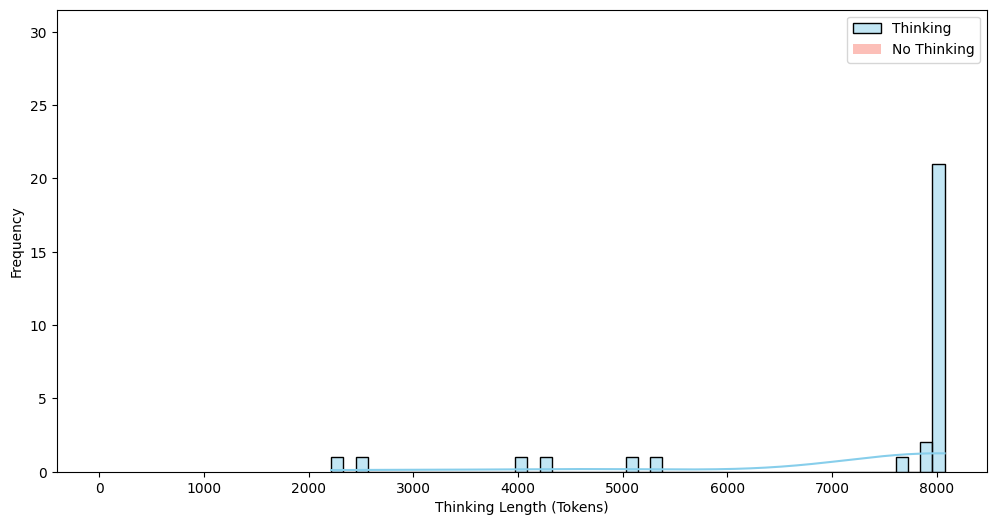

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(results_df['thinking_length'], bins=50, color='skyblue', label='Thinking', kde=True)
sns.histplot(results_df_no_thinking['thinking_length'], bins=50, color='salmon', label='No Thinking', kde=True)
plt.xlabel('Thinking Length (Tokens)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout(); plt.savefig("hist_lthink.png", dpi=150); plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_TARGET_DIR = '/content/drive/My Drive/Colab Notebooks/CSE_ML_HW1'
!mkdir -p "{DRIVE_TARGET_DIR}"
!cp -vp * "{DRIVE_TARGET_DIR}"
print(f"All files copied to {DRIVE_TARGET_DIR}!")

## 2.2 Scaling Experiments

In [ ]:
SEQ_BUDGETS = [1024, 4096, 8192, 32000]
PAR_M_VALUES = [1, 4, 8, 32]
PAR_BUDGET = 4000
MAX_ANS_TOKENS = 1024
N_RUNS = 3          # re-runs for parallel error bars
T, TOP_K, TOP_P = 0.6, 50, 0.95

In [ ]:
def run_one(llm, tokenizer, problem, budget, strategy="wait",
            temperature=0.6, top_k=50, top_p=0.95):
    end_ids, end_tag = think_end_ids(tokenizer)
    prompt   = make_prompt_think(problem, tokenizer)
    sampling = SamplingParams(
        temperature      = temperature,
        top_k            = top_k,
        top_p            = top_p,
        max_tokens       = 1,
        detokenize       = False,
    )

    token_ids = tokenizer.encode(prompt)
    prompt_len = len(token_ids)

    # ── thinking loop ─────────────────────────────────────────────────────────
    while True:
        think_len = len(token_ids) - prompt_len
        out = llm.generate({"prompt_token_ids": token_ids},
                   sampling_params=sampling,
                   use_tqdm=False)
        next_tok  = out[0].outputs[0].token_ids[0]

        if think_len >= budget:
            token_ids += end_ids
            break
        elif next_tok in end_ids and strategy == "wait":
            wait_id = tokenizer.encode("Wait", add_special_tokens=False)[0]
            token_ids.append(wait_id)
        else:
            token_ids.append(next_tok)
            if next_tok in end_ids:
                break

    # ── generate final answer ─────────────────────────────────────────────────
    ans_sampling = SamplingParams(
        temperature = temperature,
        top_k       = top_k,
        top_p       = top_p,
        max_tokens = MAX_ANS_TOKENS, detokenize=True, skip_special_tokens=False
    )
    out = llm.generate({"prompt_token_ids": token_ids},
                   sampling_params=ans_sampling,
                   use_tqdm=False)
    decoded  = out[0].outputs[0].text
    full_out = tokenizer.decode(token_ids) + decoded

    thinking  = extract_thinking_trace(full_out)
    think_tok = len(tokenizer.encode(thinking, add_special_tokens=False))
    total_tok = len(token_ids) - len(tokenizer.encode(prompt)) + len(out[0].outputs[0].token_ids)
    return full_out, think_tok, total_tok



In [ ]:
def run_sequential(budgets=SEQ_BUDGETS):
    rows = []
    for budget in budgets:
        print(f"\n── Budget {budget} ──")
        for i, ex in enumerate(dataset):
            problem = ex["prompt"][0]["content"]
            gold    = int(ex["label"])
            decoded, tlen, total = run_one(llm, tokenizer, problem, budget)
            rows.append(dict(
                budget      = budget,
                gold        = gold,
                correct_flex  = extract_answer(decoded, mode="flexible_extract") == gold,
                correct_exact = extract_answer(decoded, mode="exact_match") == gold,
                think_len   = tlen,
                total_len   = total,
            ))
            print(f"  [{i+1}/30] think_len={tlen} total={total} flex={rows[-1]['correct_flex']}")
    return pd.DataFrame(rows)

seq_df = run_sequential()
seq_df.to_csv("seq_results.csv", index=False)

In [ ]:

# 1. majority -- majority voting; 2. bom -- best-of-m
def run_parallel(m_values=PAR_M_VALUES, budget=PAR_BUDGET, n_runs=N_RUNS):
    rows = []
    for m in m_values:
        for run in range(n_runs):
            print(f"\n── m={m}  run={run+1}/{n_runs} ──")
            for i, ex in enumerate(dataset):
                problem = ex["prompt"][0]["content"]
                gold    = int(ex["label"])
                results = [run_one(llm, tokenizer, problem, budget, strategy="wait",
                                   do_sample=True, temperature=T, top_k=TOP_K, top_p=TOP_P)
                           for _ in range(m)]
                preds_flex  = [extract_answer(d, "flexible_extract") for d, *_ in results]
                preds_exact = [extract_answer(d, "exact_match")            for d, *_ in results]
                rows.append(dict(
                    m=m, run=run, gold=gold,
                    majority_flex  = majority(preds_flex)  == gold,
                    majority_exact = majority(preds_exact) == gold,
                    bom_flex       = any(p == gold for p in preds_flex),
                    bom_exact      = any(p == gold for p in preds_exact),
                    total_think    = sum(t   for _, t, _   in results),
                    total_toks     = sum(tot for _, _, tot in results),
                ))
                print(f"  [{i+1}/30] maj_flex={rows[-1]['majority_flex']} bom_flex={rows[-1]['bom_flex']}")
    return pd.DataFrame(rows)

par_df = run_parallel()
par_df.to_csv("par_results.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, col, title in zip(axes, ["correct_flex", "correct_exact"], ["Flexible", "Exact"]):
    g = seq_df.groupby("budget")[col].mean()
    ax.plot(g.index, g.values, marker="o")
    ax.set_xscale("log"); ax.set_xlabel("Thinking Budget (tokens)"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Sequential – {title}")
fig.suptitle("Sequential Scaling (greedy, wait strategy)"); plt.tight_layout()
plt.savefig("fig_sequential.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sfx, title in zip(axes, ["flex", "exact"], ["Flexible", "Exact"]):
    for col, label in [(f"majority_{sfx}", "Majority Vote"), (f"bom_{sfx}", "Best-of-m")]:
        g = par_df.groupby("m")[col].agg(["mean", "std"]).reset_index()
        x = g["m"] * PAR_BUDGET
        ax.errorbar(x, g["mean"], yerr=g["std"], label=label, marker="o", capsize=4)
    ax.set_xscale("log"); ax.set_xlabel("Total Thinking Tokens (m × budget)"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Parallel – {title}"); ax.legend()
fig.suptitle("Parallel Scaling (temp=0.6)"); plt.tight_layout()
plt.savefig("fig_parallel.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))

# Sequential: per-problem spread → horizontal error bars; no vertical (deterministic)
g = seq_df.groupby("budget").agg(
    acc =("correct_flex", "mean"),
    xmean=("total_len",   "mean"),
    xstd =("total_len",   "std"),
)
ax.errorbar(g["xmean"], g["acc"], xerr=g["xstd"],
            label="Sequential", marker="o", capsize=4)

# Parallel majority: spread across runs (vertical) and problems (horizontal)
g2 = par_df.groupby("m").agg(
    acc_mean =("majority_flex", "mean"),
    acc_std  =("majority_flex", "std"),
    tok_mean =("total_toks",    "mean"),
    tok_std  =("total_toks",    "std"),
)
ax.errorbar(g2["tok_mean"], g2["acc_mean"],
            xerr=g2["tok_std"], yerr=g2["acc_std"],
            label="Parallel (Majority)", marker="s", capsize=4)

ax.set_xlabel("Total Tokens Generated (thinking + answer)")
ax.set_ylabel("Flexible Accuracy")
ax.set_title("Accuracy vs Total Compute"); ax.legend()
plt.tight_layout(); plt.savefig("fig_total_tokens.png", dpi=150); plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_TARGET_DIR = '/content/drive/My Drive/Colab Notebooks/CSE_ML_HW1'
!mkdir -p "{DRIVE_TARGET_DIR}"
!cp -vp * "{DRIVE_TARGET_DIR}"
print(f"All files copied to {DRIVE_TARGET_DIR}!")

## 2.3 Qualitative Analysis